In [1]:
from pathlib import Path
import pandas as pd 
import glob
import numpy as np
from tqdm.autonotebook import tqdm as notebook_tqdm
notebook_tqdm.pandas()
import xgboost as xgb
from scipy.optimize import minimize_scalar
from sklearn.metrics import f1_score
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from scipy.stats import pearsonr, spearmanr

root = Path('/data/data/malpolon/xgb') 
output_path = Path('/marbec-data/RLS-Australia/malpolon/outputs/')

xgb.set_config(verbosity=0)

/tmp/ipykernel_6542/2875164467.py:5: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm as notebook_tqdm


In [2]:
## Load targets and Deep-SDM predictions
fulldf = pd.read_csv(root / 'database_split.csv', index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})

xgb_f1 = pd.read_csv(root / f'xgbmm-test-f1.csv', index_col = 0)
rf_f1 = pd.read_csv(root / f'rf2-test-f1.csv', index_col = 0)
#mm_f1 = pd.read_csv(root / f'all-test-f1-mm.csv', index_col = 0)
#loop_f1 = pd.read_csv(root / f'allloop-test-f1.csv', index_col = 0)
#loop2_f1 = pd.read_csv(root / f'allloop2-test-f1.csv', index_col = 0)
#mlp_f1 = pd.read_csv(root / f'allmlp-test-f1.csv', index_col = 0)
#mlp2_f1 = pd.read_csv(root / f'allmlp2-test-f1.csv', index_col = 0)

cp = '26_hum_env_dhw_bathy_common_pa-2025-11-10_16-31'
mm_f1 = pd.read_csv(next((output_path / cp).glob("testF1*.csv")), index_col = 0)

# # cp = '31_hum_env_dhw_bathy_common_pa-2025-11-12_15-13'
# # deepxgb_f1 = pd.read_csv(next((output_path / cp).glob("testF1*.csv")), index_col = 0)

cp = '15_humenv_cat_pa-2025-10-27_11-39'
envhum_f1 = pd.read_csv(next((output_path / cp).glob("testF1*.csv")), index_col = 0)

cp = '37_mm4_transductif-2025-12-02_12-47'
td_f1 = pd.read_csv(next((output_path / cp).glob("testF1*.csv")), index_col = 0)

## Prepare data

In [ ]:
def get_compound_values(row):

    survey_id = row.name
    
    inputs_path = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/')

    filename = Path(inputs_path) / "env" / (str(survey_id) + '.npy')
    x = np.load(filename).astype(np.float32)
    env = np.transpose(x, (2, 0, 1))

    filename = Path(inputs_path) / "hum" / (str(survey_id) + '.npy')
    x = np.load(filename).astype(np.float32)
    hum = np.transpose(x, (2, 0, 1))

    envhum = np.concatenate([env, hum], axis=0)

    center_values = 0.25 * (envhum[:, 16, 16] + envhum[:, 15, 16] + envhum[:, 16, 15] + envhum[:, 15, 15])
    means = np.mean(envhum, axis=(1,2))
    deviations = np.std(envhum, axis=(1,2)) / means


    filename = Path(inputs_path) / "dhw" / (str(survey_id) + '.npy')
    dhw = np.load(filename).astype(np.float32)
    dhw_vect = np.array([np.mean(dhw), np.std(dhw) / np.mean(dhw), np.max(dhw)])

    return np.concatenate([center_values, means, deviations, dhw_vect])


  3%|▎         | 741/27437 [03:19<1:54:45,  3.88it/s]/tmp/ipykernel_79695/1252176004.py:24: RuntimeWarning: invalid value encountered in scalar divide
  dhw_vect = np.array([np.mean(dhw), np.std(dhw) / np.mean(dhw), np.max(dhw)])
  3%|▎         | 758/27437 [03:24<2:10:29,  3.41it/s]/tmp/ipykernel_79695/1252176004.py:19: RuntimeWarning: invalid value encountered in divide
  deviations = np.std(envhum, axis=(1,2)) / means
100%|██████████| 27437/27437 [2:06:57<00:00,  3.60it/s]  


In [ ]:
X = fulldf[['subset']].progress_apply(get_compound_values, axis=1, result_type='expand')
X.to_csv(root / f'X_compound_values_mm.csv')

## Train

In [ ]:
# Prepare datasets

def get_datasets(sp, type='rf'):

    #X
    X = pd.read_csv(root / f'X_compound_values_mm.csv', index_col = 0)
    X_train = X.loc[fulldf['subset'] == 'train']
    X_val = X.loc[fulldf['subset'] == 'val']
    X_test = X.loc[fulldf['subset'] == 'test']

    # Y
    targets = (fulldf[sp] > 0).astype(int)
    Y_train = targets.loc[fulldf['subset'] == 'train']
    Y_val = targets.loc[fulldf['subset'] == 'val']
    Y_test = targets.loc[fulldf['subset'] == 'test']

    if type == 'xgb':

        dtrain_clf = xgb.DMatrix(X_train, Y_train, enable_categorical=True)
        dval_clf = xgb.DMatrix(X_val, Y_val, enable_categorical=True)
        dtest_clf = xgb.DMatrix(X_test, Y_test, enable_categorical=True)

        return dtrain_clf, dval_clf, dtest_clf
    
    else:

        return X_train, Y_train, X_val, Y_val, X_test, Y_test

#### P-A

In [ ]:
for sp in notebook_tqdm(td_f1.index.to_list()):

   # Train XGBoost classifier

   # dtrain_clf, dval_clf, dtest_clf = get_datasets(sp, 'XGB')
   # evals = [(dtrain_clf, "train"), (dval_clf, "validation")]

   # params = {"objective": "binary:logistic", "tree_method": "hist", "device": "cuda","subsample":0.3,"max_depth":5,"eval_metric":"auc","base_score":0.5}
   # n=500

   # model = xgb.train(
   #    params=params,
   #    dtrain=dtrain_clf,
   #    num_boost_round=n,
   #    evals=evals,
   #    verbose_eval=10
   # )

   # targets = (fulldf[sp] > 0).astype(float)
   # Y_train = targets.loc[fulldf['subset'] == 'train'].astype('category')
   # Y_val = targets.loc[fulldf['subset'] == 'val'].astype('category')
   # Y_test = targets.loc[fulldf['subset'] == 'test'].astype('category')

   # print(sp)
   # pd.Series(model.predict(dtrain_clf), name=sp, index = Y_train.index).to_csv(root / 'xgb-preds' / f"train_{sp.replace('/','-')}.csv")
   # pd.Series(model.predict(dval_clf), name=sp, index = Y_val.index).to_csv(root / 'xgb-preds' / f"val_{sp.replace('/','-')}.csv")
   # pd.Series(model.predict(dtest_clf), name=sp, index = Y_test.index).to_csv(root / 'xgb-preds' / f"test_{sp.replace('/','-')}.csv")

   

   # Train RF classifier

   X_train, Y_train, X_val, Y_val, X_test, Y_test = get_datasets(sp)
   regr = RandomForestRegressor(min_samples_split=2, # Useless
                                min_samples_leaf=3,
                                max_leaf_nodes=None,
                                n_estimators=300,
                                max_depth=None,
                                random_state=0,
                                n_jobs=32)

   # Export predictions

   regr.fit(X_train, Y_train)
   # Export predictions

   pd.Series(regr.predict(X_val), name=sp, index = Y_val.index).to_csv(root / 'rf-preds' / f"val_{sp.replace('/','-')}.csv")
   pd.Series(regr.predict(X_test), name=sp, index = Y_test.index).to_csv(root / 'rf-preds' / f"test_{sp.replace('/','-')}.csv")

   

100%|██████████| 817/817 [1:45:33<00:00,  7.75s/it]


#### Classif

In [ ]:
nbins = 5

fulldf = pd.read_csv(root / f"database_common_{nbins}binned.csv", index_col='survey_id',
                     dtype = {22:str, 24:str, 25:str})


In [ ]:
for sp in notebook_tqdm(td_f1.index.to_list()):

   # Train XGBoost classifier

   # dtrain_clf, dval_clf, dtest_clf = get_datasets(sp, 'XGB')
   # evals = [(dtrain_clf, "train"), (dval_clf, "validation")]

   # params = {"objective": "binary:logistic", "tree_method": "hist", "device": "cuda","subsample":0.3,"max_depth":5,"eval_metric":"auc","base_score":0.5}
   # n=500

   # model = xgb.train(
   #    params=params,
   #    dtrain=dtrain_clf,
   #    num_boost_round=n,
   #    evals=evals,
   #    verbose_eval=10
   # )

   # targets = (fulldf[sp] > 0).astype(float)
   # Y_train = targets.loc[fulldf['subset'] == 'train'].astype('category')
   # Y_val = targets.loc[fulldf['subset'] == 'val'].astype('category')
   # Y_test = targets.loc[fulldf['subset'] == 'test'].astype('category')

   # print(sp)
   # pd.Series(model.predict(dtrain_clf), name=sp, index = Y_train.index).to_csv(root / 'xgb-preds' / f"train_{sp.replace('/','-')}.csv")
   # pd.Series(model.predict(dval_clf), name=sp, index = Y_val.index).to_csv(root / 'xgb-preds' / f"val_{sp.replace('/','-')}.csv")
   # pd.Series(model.predict(dtest_clf), name=sp, index = Y_test.index).to_csv(root / 'xgb-preds' / f"test_{sp.replace('/','-')}.csv")

   

   # Train RF classifier

   X_train, Y_train, X_val, Y_val, X_test, Y_test = get_datasets(sp)
   regr = RandomForestRegressor(min_samples_split=2, # Useless
                                min_samples_leaf=3,
                                max_leaf_nodes=None,
                                n_estimators=300,
                                max_depth=None,
                                random_state=0,
                                n_jobs=32)

   # Export predictions

   regr.fit(X_train, Y_train)
   # Export predictions

   pd.Series(regr.predict(X_val), name=sp, index = Y_val.index).to_csv(root / 'rf-preds' / f"val_{sp.replace('/','-')}.csv")
   pd.Series(regr.predict(X_test), name=sp, index = Y_test.index).to_csv(root / 'rf-preds' / f"test_{sp.replace('/','-')}.csv")

#### Biomass

In [50]:
# Prepare datasets

def get_datasets_bm(sp):

    #X
    X = pd.read_csv(root / f'X_compound_values_mm.csv', index_col = 0)
    X = X.loc[:,~X.isna().any()]
    X_train = X.loc[fulldf['subset'] == 'train']
    X_val = X.loc[fulldf['subset'] == 'val']
    X_test = X.loc[fulldf['subset'] == 'test']

    # Y
    targets = fulldf[sp].astype(float)
    Y_train = targets.loc[fulldf['subset'] == 'train']
    Y_val = targets.loc[fulldf['subset'] == 'val']
    Y_test = targets.loc[fulldf['subset'] == 'test']

    #return pd.concat([X_train, X_val]), pd.concat([Y_train, Y_val]), X_test, Y_test
    return X_train, Y_train, X_test, Y_test

In [51]:
for sp in notebook_tqdm(td_f1.index.to_list()):

   # Train

   X_train, Y_train, X_test, Y_test= get_datasets_bm(sp)

   regr = RandomForestRegressor(min_samples_split=2, # Useless
                                min_samples_leaf=3,
                                max_leaf_nodes=None,
                                n_estimators=300,
                                max_depth=None,
                                max_features=3,
                                random_state=0,
                                n_jobs=32)

   regr.fit(X_train, Y_train)
   # Export predictions

   pd.Series(regr.predict(X_test), name=sp, index = Y_test.index).to_csv(root / 'xgb-preds-bm' / f"test2_{sp.replace('/','-')}.csv")

100%|██████████| 817/817 [11:27<00:00,  1.19it/s]


## Calculate threshold

In [73]:
dfdict = {}

for sp in notebook_tqdm(td_f1.index.to_list()):

    dfdict[sp] = pd.read_csv(root / 'rf-preds' / f"val_{sp.replace('/','-')}.csv", index_col=0).squeeze()

xgb_val = pd.DataFrame(dfdict)


100%|██████████| 817/817 [00:02<00:00, 289.80it/s]


In [74]:
# Find best threshold for species richness

def rvalue(thres, df, target_sr):
    sr = (df > thres).astype(int).sum(axis=1)
    
    return np.abs(sr.mean() - target_sr.mean())



targets_sr = (fulldf.loc[xgb_val.index, xgb_val.columns] > 0).sum(axis=1)
threshold = minimize_scalar(rvalue, args=(xgb_val, targets_sr),method='Bounded', bounds=(0,1))['x']
print(threshold)

0.3055327147141442


## Calculate F1

In [75]:
THRESHOLD = 0.306

dfdict = {}

for sp in notebook_tqdm(td_f1.index.to_list()):

    dfdict[sp] = pd.read_csv(root / 'xgb-preds' / f"test_{sp.replace('/','-')}.csv", index_col=0).squeeze()

xgb_test = (pd.DataFrame(dfdict) > THRESHOLD)

100%|██████████| 817/817 [00:02<00:00, 397.27it/s]


In [ ]:
## Save to files as inputs
xgbtest = pd.DataFrame(dfdict)
outfolder = Path('/marbec-data/RLS-Australia/malpolon/inputs/australia/xgbmm')

for s in notebook_tqdm(xgbtest.index.to_list()):
    np.save(outfolder / str(s), xgbtest.loc[s].values)

In [76]:
# Calculate average precision
scorename = 'f1' # / AP

dic = {}
for s in xgb_test.columns:
    preds = (xgb_test[s] > THRESHOLD).astype(float).to_numpy().flatten()
    targ = (fulldf.loc[xgb_test.index, s] > 0).astype(float).to_numpy().flatten()
    f1 = f1_score(targ, preds)
    dic[s] = {'f1': f1}
scores = pd.DataFrame(dic).T      

/data/venvs/xgb/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.

/data/venvs/xgb/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.

/data/venvs/xgb/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.

/data/venvs/xgb/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning:

F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.



In [77]:
xgb_f1 = scores.sort_values(by=scorename, ascending=False)
xgb_f1.to_csv(root / f'rf2-test-{scorename}.csv')

## Calculate R2

In [52]:
dfdict = {}

for sp in notebook_tqdm(td_f1.index.to_list()):

    dfdict[sp] = pd.read_csv(root / 'xgb-preds-bm' / f"test2_{sp.replace('/','-')}.csv", index_col=0).squeeze()

preds_test = pd.DataFrame(dfdict)

100%|██████████| 817/817 [00:02<00:00, 348.74it/s]


In [53]:
dic = {}
for s in preds_test.columns:
    preds = preds_test[s]
    targ = fulldf.loc[preds_test.index, s]
    dic[s] = {'pearsonr': pearsonr(preds, targ)[0],
               'spearmanr': spearmanr(preds, targ)[0]}
scores = pd.DataFrame(dic).T      

/tmp/ipykernel_13168/3407003587.py:5: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  dic[s] = {'pearsonr': pearsonr(preds, targ)[0],
/tmp/ipykernel_13168/3407003587.py:6: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  'spearmanr': spearmanr(preds, targ)[0]}


In [54]:
scores.sort_values(by='pearsonr', ascending=False).to_csv(root / 'rf2-bm-test.csv')

## Compare

In [3]:
scores = pd.concat([rf_f1["f1"], xgb_f1["f1"], envhum_f1["f1"], mm_f1["f1"], td_f1["f1"]], axis = 1)
names = ['RF', 'XGBoost', 'Deep-SDM', 'Multimodal', 'Transductive']
scores.columns = names

In [4]:
scores.dropna(inplace=True)

#### 1v1 Bland-Altman

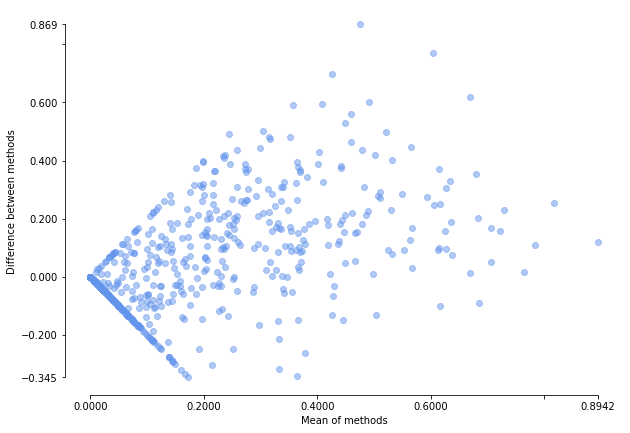

In [13]:
import pyCompare

pyCompare.blandAltman(scores[names[3]].values,scores[names[0]].values)

#### 1v1 Scatter plot

[Text(0.5, 0, 'XGBoost F1'), Text(0, 0.5, 'Transductif F1')]

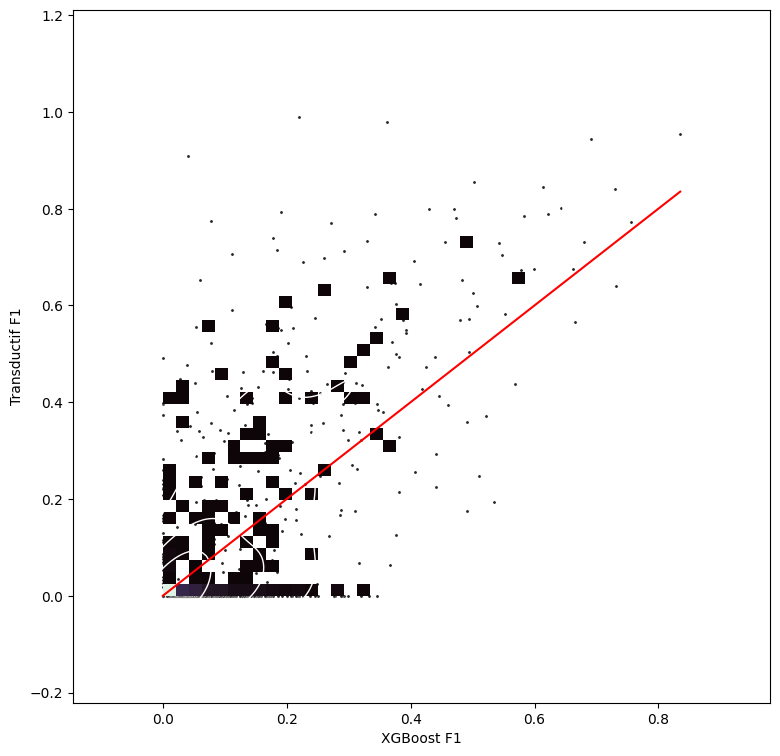

In [14]:
import seaborn as sns
from matplotlib import pyplot as plt

x, y = scores[names[0]].values, scores[names[3]].values

# Draw a combo histogram and scatterplot with density contours
f, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(x=x, y=y, s=5, color=".15")
sns.histplot(x=x, y=y, bins=40, pthresh=.1, cmap="mako")
sns.kdeplot(x=x, y=y, levels=5, color="w", linewidths=1)
sns.lineplot(x=[min(x), max(x)], y=[min(x), max(x)],color='red')
ax.set(xlabel=names[0] + ' F1', ylabel=names[3] + ' F1')

#### XvX lineplot

In [4]:
y = []

for n in names:
    y1 = scores[[n]].sort_values(ascending=False, by=n)
    y1.reset_index(inplace=True)
    y1.columns = ['species', 'F1']
    y1['x'] = np.arange(len(y1))
    y1['model'] = n
    y.append(y1)

data = pd.concat(y)

In [5]:
import plotly.express as px

fig = px.line(data[data['x'] <= 400], x='x', y='F1', color='model', template = 'simple_white',
           width = 800, height=800,
           color_discrete_sequence = px.colors.qualitative.Pastel)

fig.update_layout(
    xaxis_title='Species rank',
    yaxis_title='F1 score',
    font=dict(size=20),
    legend_title_text='',
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)

fig.update_traces(line={'width': 4})

#### 1v1 arrow scatter

In [62]:
scores['av'] = np.maximum(scores[names[0]], scores[names[3]])

<Axes: >

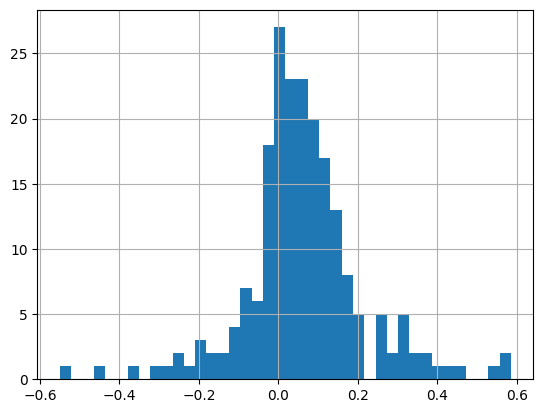

In [28]:
best_scores = scores[scores['av'] > 0.3]
(best_scores[names[3]] - best_scores[names[2]]).hist(bins=40)

In [63]:
best_scores = scores.sort_values(by='XGBoost', ascending=False)
best_scores = best_scores[best_scores['av'] > 0.4]
best_scores['x'] = np.arange(len(best_scores))

In [65]:
import plotly.graph_objects as go
import numpy as np

# Example data
x = best_scores['x']
y1 = best_scores['XGBoost']
y2 = best_scores['Transductif']
hover_text = best_scores.index.to_list()

# Create the figure
fig = go.Figure()

# Add the two series as scatter plots
fig.add_trace(go.Scatter(
    x=x, y=y1,
    mode='markers',
    marker=dict(color=px.colors.qualitative.Pastel[0], size=10),
    name='XGBoost',
    hovertext=hover_text,
    hoverinfo='text'
))

fig.add_trace(go.Scatter(
    x=x, y=y2,
    mode='markers',
    marker=dict(color=px.colors.qualitative.Pastel[3], size=10),
    name='Transductive',
    hovertext=hover_text,
    hoverinfo='text'
))

# Add arrows for the differences
for i in range(len(x)):
    fig.add_annotation(
        ax=x[i], ay=y1[i],
        axref='x', ayref='y',
        x=x[i], y=y2[i],
        xref='x', yref='y',
        showarrow=True,
        arrowhead=1,
        arrowsize=1.5,
        arrowcolor=px.colors.qualitative.Pastel1[1],
        arrowwidth=1.5,
    )


fig.update_layout(
    template='simple_white',
    width = 1200, height=800,
    xaxis_title='Species rank',
    yaxis_title='F1 score',
    font=dict(size=20),
    legend=dict(yanchor="top",
                y=0.99,
                xanchor="right",
                x=0.99)
)


/tmp/ipykernel_46397/3715843393.py:35: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_46397/3715843393.py:37: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

